In [20]:

from pathlib import Path
import torch
import pandas as pd



### Setup save directory to save the data 

### Load data and validate the data 

In [21]:
from src.dataloader import LoadForecastDataLoader

loader = LoadForecastDataLoader(

    csv_path="Data/synthetic_ireland_national_hourly.csv",

    datetime_col="timestamp_local",
    # datetime_format="%Y-%m-%dT%H:%M:%S%z", # define a datetime format if the datetime column is not in a standard format
    features=[
        "hour", "day_of_week", "month",
        "mean_wind_speed", "wind_capacity_weighted_wind_speed","wind_speed_squared","wind_speed_lag_1h",
        "mean_temperature","temperature_lag_1h",
    ],

    target="wind_generation_mw",

    lookback=48,

    horizon=24,

    expected_frequency="1h"
)

SAVE_DIR = Path(f"models/generation_transformer/{loader.lookback}_lookback_{loader.horizon}_horizon_syn")

In [22]:
# from src.dataloader import LoadForecastDataLoader

# loader = LoadForecastDataLoader(

#     csv_path="Data/synthetic_ireland_national_hourly.csv",

#     datetime_col="timestamp_local",
#     # datetime_format="%Y-%m-%dT%H:%M:%S%z", # define a datetime format if the datetime column is not in a standard format
#     features=[
#         "hour", "day_of_week", "month",
#         "mean_wind_speed", "consumption_lag_1h","consumption_lag_24h",
#         "mean_temperature","temperature_lag_1h",
#     ],

#     target="total_electricity_consumption_mw",

#     lookback=48,

#     horizon=24,

#     expected_frequency="1h"
# )



# SAVE_DIR = Path(f"models/consumption_transformer/{loader.lookback}_lookback_{loader.horizon}_horizon_syn")

In [23]:

# ============================================================
# Model save directory
# ============================================================

# SAVE_DIR = Path(f"models/generation_transformer/{loader.lookback}_lookback_{loader.horizon}_horizon_syn")

SAVE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = SAVE_DIR / "best_lstm.pt"

In [24]:
df_all = loader.get_dataframe()

In [25]:
df_all

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26299,2024-12-31 19:00:00+00:00,2024-12-31T19:00:00+00:00,19,1,12,0,winter,0,9.42,9.72,...,1419.9,0.0,2452.2,587.7,1419.9,31.84,29.3,4526.7,4583.9,0.54431
26300,2024-12-31 20:00:00+00:00,2024-12-31T20:00:00+00:00,20,1,12,0,winter,0,8.83,9.16,...,969.6,0.0,2504.7,619.6,969.6,23.68,-135.2,4430.5,4409.9,1.29025
26301,2024-12-31 21:00:00+00:00,2024-12-31T21:00:00+00:00,21,1,12,0,winter,0,8.99,9.20,...,846.6,0.0,2606.5,623.6,846.6,20.77,-89.6,4229.1,4164.1,-1.05788
26302,2024-12-31 22:00:00+00:00,2024-12-31T22:00:00+00:00,22,1,12,0,winter,0,8.92,9.16,...,686.6,0.0,2466.4,633.0,686.6,18.14,-159.3,4166.3,4042.7,-1.01784


### seperate the data [Not necessay but done here just to test]

In [26]:
start_date = "2022-01-01"
end_date = "2023-03-31"

df = df_all[
    (df_all["timestamp_local"] >= start_date) &
    (df_all["timestamp_local"] <= end_date)
]

In [27]:
loader.summary()


DATASET SUMMARY
File:       Data\synthetic_ireland_national_hourly.csv
Rows:       26304
Columns:    34
Datetime:   timestamp_local
Features:   ['hour', 'day_of_week', 'month', 'mean_wind_speed', 'wind_capacity_weighted_wind_speed', 'wind_speed_squared', 'wind_speed_lag_1h', 'mean_temperature', 'temperature_lag_1h']
Target:     ['wind_generation_mw']
Lookback:   48
Horizon:    24
Frequency:  1h
Start:      2022-01-01 00:00:00+00:00
End:        2024-12-31 23:00:00+00:00

Abnormalities:
- numeric_abnormalities: {'mean_temperature': {'negative_values': 29}, 'temperature_lag_1h': {'negative_values': 26}}



In [28]:
df

,timestamp_local,timestamp_utc,hour,day_of_week,month,weekend_flag,season,daylight_flag,mean_temperature,population_weighted_temperature,...,wind_generation_mw,solar_generation_mw,gas_generation_mw,other_generation_mw,renewable_generation_mw,renewable_generation_percentage,net_exports_mw,consumption_lag_1h,consumption_lag_24h,random_control
0,2022-01-01 00:00:00+00:00,2022-01-01T00:00:00+00:00,0,5,1,1,winter,0,1.28,1.19,...,1346.9,0.0,2071.1,567.5,1346.9,33.80,20.8,4396.2,4061.7,-0.51891
1,2022-01-01 01:00:00+00:00,2022-01-01T01:00:00+00:00,1,5,1,1,winter,0,1.64,1.57,...,1553.2,0.0,1593.1,571.1,1553.2,41.78,41.3,3964.7,4049.0,-0.21422
2,2022-01-01 02:00:00+00:00,2022-01-01T02:00:00+00:00,2,5,1,1,winter,0,0.57,0.46,...,1436.1,0.0,1732.7,576.8,1436.1,38.34,-15.3,3676.1,3926.0,0.46331
3,2022-01-01 03:00:00+00:00,2022-01-01T03:00:00+00:00,3,5,1,1,winter,0,0.15,-0.02,...,2370.6,0.0,882.2,589.2,2370.6,61.70,128.6,3760.9,3887.3,-0.14404
4,2022-01-01 04:00:00+00:00,2022-01-01T04:00:00+00:00,4,5,1,1,winter,0,-0.08,-0.28,...,1655.3,0.0,1666.3,613.4,1655.3,42.07,102.1,3713.4,4013.0,-0.44085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10892,2023-03-30 20:00:00+00:00,2023-03-30T20:00:00+00:00,21,3,3,0,spring,0,10.59,10.57,...,1173.5,0.0,2252.3,551.4,1173.5,29.51,-84.4,4311.2,3885.9,-1.33274
10893,2023-03-30 21:00:00+00:00,2023-03-30T21:00:00+00:00,22,3,3,0,spring,0,10.14,10.05,...,1044.4,0.0,2175.0,551.8,1044.4,27.69,-126.1,4061.6,3621.3,0.84834
10894,2023-03-30 22:00:00+00:00,2023-03-30T22:00:00+00:00,23,3,3,0,spring,0,9.83,9.82,...,1224.8,0.0,2035.6,554.6,1224.8,32.10,0.5,3897.3,3482.8,-0.02053
10895,2023-03-30 23:00:00+00:00,2023-03-30T23:00:00+00:00,0,4,3,0,spring,0,9.50,9.53,...,1147.5,0.0,1885.8,534.5,1147.5,32.16,-3.6,3814.5,3207.9,1.21485


### Train, Test and Validation data set seperation

In [29]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

### Data normalization [Scaling]

In [30]:
from sklearn.preprocessing import StandardScaler


features = loader.features
target = loader.target


feature_scaler = StandardScaler()
target_scaler = StandardScaler()


# Fit ONLY on training data
feature_scaler.fit(
    train_df[features]
)

target_scaler.fit(
    train_df[target]
)


# Transform all datasets
train_features = feature_scaler.transform(
    train_df[features]
)

val_features = feature_scaler.transform(
    val_df[features]
)

test_features = feature_scaler.transform(
    test_df[features]
)


train_target = target_scaler.transform(
    train_df[target]
)

val_target = target_scaler.transform(
    val_df[target]
)

test_target = target_scaler.transform(
    test_df[target]
)

In [59]:
feature_scaler

StandardScaler()

### Preperaing data for lstm model lookback [t-n we plan to use as look back], horizon [t -> t+n we plan to forecast]

In [31]:
from src.models.lstm import LSTMDataset
# setup dataset to train 
train_dataset = LSTMDataset(
    train_features,
    train_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

val_dataset = LSTMDataset(
    val_features,
    val_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

test_dataset = LSTMDataset(
    test_features,
    test_target,
    lookback=loader.lookback,
    horizon=loader.horizon
)

### Dataload, help load the data for train and testing 
Batch size define the size of data we plan to feed in on go, and shuffle -[True refer to randominzing data false result to sequential feeding]

In [32]:
from torch.utils.data import DataLoader


BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

###### Checking how the data is generated

In [33]:
X, y = next(iter(train_loader))

print("X:", X.shape)
print("y:", y.shape)

X: torch.Size([64, 48, 9])
y: torch.Size([64, 24, 1])


In [34]:
X

tensor([[[-0.6494,  1.4906, -0.5841,  ..., -0.0742, -0.2723, -0.3980],
         [-0.5049,  1.4906, -0.5841,  ..., -0.0169, -0.1871, -0.2972],
         [-0.3604,  1.4906, -0.5841,  ...,  0.1436, -0.1064, -0.1739],
         ...,
         [-1.0829, -1.0006, -0.5841,  ..., -1.3162, -0.0727, -0.1178],
         [-0.9384, -1.0006, -0.5841,  ..., -2.1607, -0.0077, -0.0573],
         [-0.7939, -1.0006, -0.5841,  ..., -2.1721, -0.0279,  0.0166]],

        [[ 1.2292,  0.9924,  0.4088,  ...,  0.2085,  1.2123,  1.2898],
         [ 1.3737,  0.9924,  0.4088,  ...,  1.0683,  1.1877,  1.1329],
         [ 1.5182,  0.9924,  0.4088,  ...,  1.0378,  0.9881,  1.1307],
         ...,
         [ 0.7957, -1.4989,  0.4088,  ..., -0.1277,  1.9659,  1.9735],
         [ 0.9402, -1.4989,  0.4088,  ...,  0.1894,  1.7954,  1.9825],
         [ 1.0847, -1.4989,  0.4088,  ..., -0.2921,  1.6541,  1.7942]],

        [[-0.3604,  0.4941, -0.5841,  ..., -1.1022,  0.0237, -0.0887],
         [-0.2159,  0.4941, -0.5841,  ..., -1

### Setting up LSTM model, LSTMForecast help to setup a model

In [35]:
from src.models.transformer import TransformerForecast
from torch import nn

INPUT_SIZE = len(loader.features)
model = TransformerForecast(

    input_size=INPUT_SIZE,

    d_model=64,

    nhead=4,

    num_layers=2,

    horizon=loader.horizon,

    dropout=0.2

)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
) # setting up device GPU or CPU for training

model = model.to(device) # the setup model to device GPU or CPU for training

print(device)

criterion = nn.MSELoss() # training loss function for regression tasks

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
) # optimizer for training the model, using Adam optimization algorithm with a learning rate of 0.001

cpu


### Training and Validation funtion for single step

In [36]:
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    for X, y in dataloader:

        X = X.to(device)
        y = y.to(device)

        # Clear gradients
        optimizer.zero_grad()

        # Forward pass
        prediction = model(X)

        # print(prediction.shape, y.shape)
        # Calculate loss
        loss = criterion(
            prediction,
            y
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

In [37]:
def validate(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        for X, y in dataloader:

            X = X.to(device)
            y = y.to(device)

            prediction = model(X)

            loss = criterion(
                prediction,
                y
            )

            total_loss += loss.item()

    return (
        total_loss / len(dataloader)
    )

### Traning the model an saving

In [38]:

EPOCHS = 30

best_val_loss = float("inf")

train_losses = []
val_losses = []


for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} "
        f"| Train: {train_loss:.5f} "
        f"| Val: {val_loss:.5f}"
    )

    # Save best model
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(
            f"  -> Best model saved to: "
            f"{BEST_MODEL_PATH}"
        )

Epoch 01/30 | Train: 0.69606 | Val: 0.99780
  -> Best model saved to: models\generation_transformer\48_lookback_24_horizon_syn\best_lstm.pt
Epoch 02/30 | Train: 0.63267 | Val: 1.16571
Epoch 03/30 | Train: 0.59812 | Val: 1.06714
Epoch 04/30 | Train: 0.56814 | Val: 1.23529
Epoch 05/30 | Train: 0.54644 | Val: 1.11824
Epoch 06/30 | Train: 0.51377 | Val: 1.39717
Epoch 07/30 | Train: 0.48370 | Val: 1.26625
Epoch 08/30 | Train: 0.45654 | Val: 1.37262
Epoch 09/30 | Train: 0.43294 | Val: 1.33181
Epoch 10/30 | Train: 0.40617 | Val: 1.34603
Epoch 11/30 | Train: 0.39344 | Val: 1.26539
Epoch 12/30 | Train: 0.38056 | Val: 1.43871
Epoch 13/30 | Train: 0.36083 | Val: 1.39440
Epoch 14/30 | Train: 0.34800 | Val: 1.46155
Epoch 15/30 | Train: 0.34023 | Val: 1.46713
Epoch 16/30 | Train: 0.32659 | Val: 1.49067
Epoch 17/30 | Train: 0.31740 | Val: 1.44532
Epoch 18/30 | Train: 0.29737 | Val: 1.51235
Epoch 19/30 | Train: 0.32274 | Val: 1.39550
Epoch 20/30 | Train: 0.29479 | Val: 1.56916
Epoch 21/30 | Train: 0.2

### Loading model

In [39]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device
    )
)

model.eval()

TransformerForecast(
  (input_projection): Linear(in_features=9, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=2048, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=2048, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=24, bias=True)
)

## Sliding window forecast
### Testing the model

In [40]:
import numpy as np


predictions = []
actuals = []


with torch.no_grad():

    for X, y in test_loader:

        X = X.to(device)

        prediction = model(X)

        predictions.append(
            prediction.cpu().numpy()
        )

        actuals.append(
            y.numpy()
        )


predictions = np.concatenate(
    predictions,
    axis=0
)

actuals = np.concatenate(
    actuals,
    axis=0
)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Actual:",
    actuals.shape
)

Predictions: (1564, 24, 1)
Actual: (1564, 24, 1)


In [41]:
predictions[1,:,:]

array([[0.6531857 ],
       [0.90859383],
       [0.83030427],
       [0.69860655],
       [0.9296903 ],
       [0.8093223 ],
       [0.9113264 ],
       [0.9130698 ],
       [1.0197222 ],
       [0.8648308 ],
       [1.0050384 ],
       [1.166935  ],
       [0.999579  ],
       [0.83790326],
       [1.0632961 ],
       [1.0628971 ],
       [1.033524  ],
       [1.1059405 ],
       [1.254215  ],
       [1.1457757 ],
       [1.2451731 ],
       [1.3268871 ],
       [1.2739027 ],
       [1.3233536 ]], dtype=float32)

### Coverting the data back to original 
As to train the model we Scale them using mean and std 

In [42]:
predictions_original = (
    target_scaler
    .inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler
    .inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

# ---------------------------------------
# 2. Get test timestamps
# ---------------------------------------

test_timestamps = test_df[loader.datetime_col].reset_index(drop=True)


# ---------------------------------------
# 3. Create rows for every forecast horizon
# ---------------------------------------

results = []

for i in range(len(predictions_original)):

    forecast_start = loader.lookback + i

    for h in range(loader.horizon):

        timestamp_index = forecast_start + h

        # Make sure timestamp exists
        if timestamp_index >= len(test_timestamps):
            break

        results.append({
            "datetime": test_timestamps.iloc[timestamp_index],
            "actual": actuals_original[i, h, 0],
            "predicted": predictions_original[i, h, 0]
        })


# ---------------------------------------
# 4. Convert to DataFrame
# ---------------------------------------

results_df = pd.DataFrame(results)

print(results_df.head())
print(results_df.shape)

                   datetime       actual    predicted
0 2023-01-23 22:00:00+00:00   806.099976  1730.145142
1 2023-01-23 23:00:00+00:00   899.099976  1922.185181
2 2023-01-24 00:00:00+00:00  1015.299988  1854.474365
3 2023-01-24 01:00:00+00:00  1962.399902  1716.775635
4 2023-01-24 02:00:00+00:00  1655.000000  1905.706909
(37536, 3)


#### evaluating the results with MAE and RMSE

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  669.63
RMSE: 809.61


Pred shape: (37536,)
Act shape: (37536,)


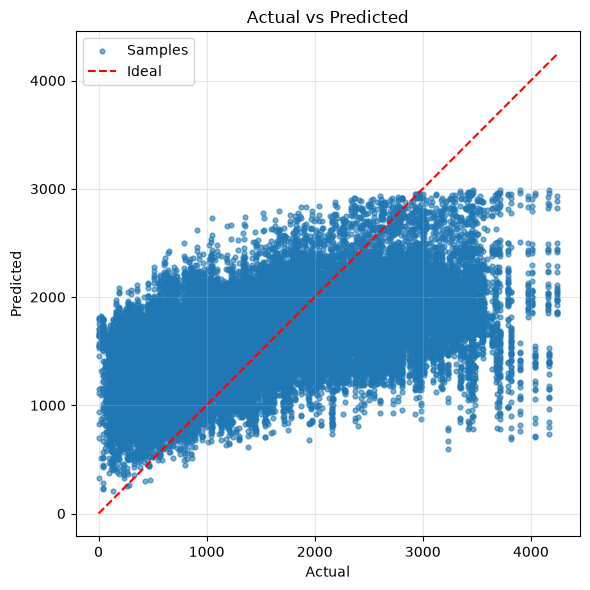

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


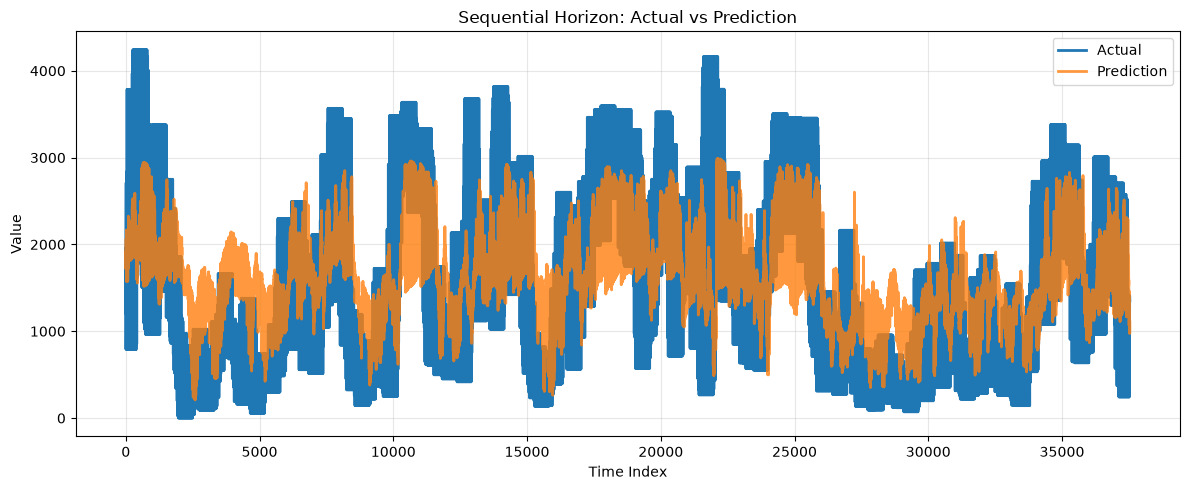

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Flatten in case they are (N,1)
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

# Create a time index
t = np.arange(len(pred))

plt.figure(figsize=(12,5))
plt.plot(t, act, label="Actual", linewidth=2)
plt.plot(t, pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title("Sequential Horizon: Actual vs Prediction")
plt.xlabel("Time Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


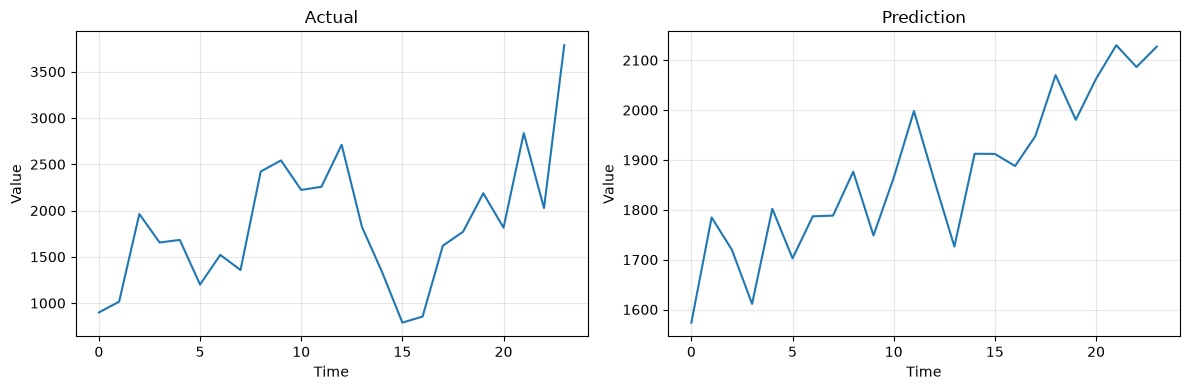

In [46]:
import matplotlib.pyplot as plt

# Select sample index
i = 1

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

# --- Actual ---
plt.subplot(1, 2, 1)
plt.plot(actual)
plt.title("Actual")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

# --- Prediction ---
plt.subplot(1, 2, 2)
plt.plot(pred)
plt.title("Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


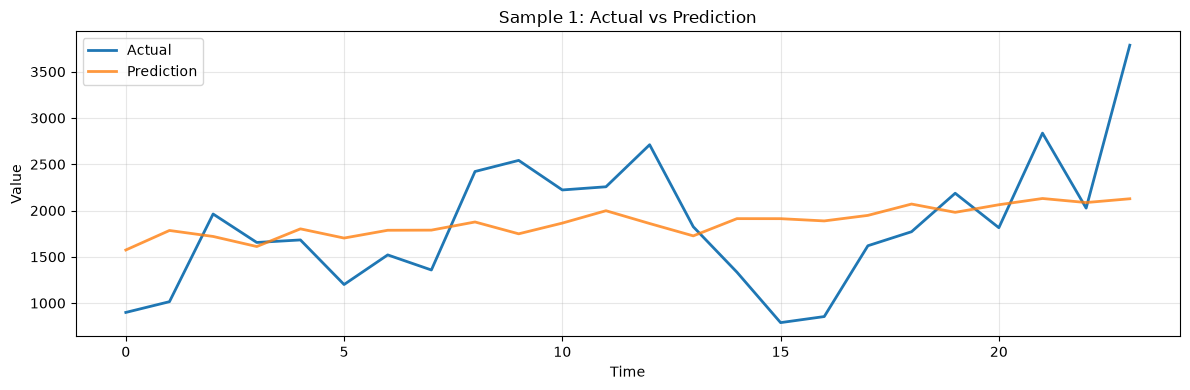

In [47]:
# Select sample index
i = 1

actual = actuals_original[i, :, :]
pred   = predictions_original[i, :, :]

plt.figure(figsize=(12,4))

plt.plot(actual, label="Actual", linewidth=2)
plt.plot(pred, label="Prediction", linewidth=2, alpha=0.8)

plt.title(f"Sample {i}: Actual vs Prediction")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


In [48]:
predictions = []
actuals = []
forecast_datetimes = []

model.eval()

with torch.no_grad():

    for i, (X, y) in enumerate(test_loader):

        X = X.to(device)

        prediction = model(X)

        prediction = prediction.cpu().numpy()
        actual = y.numpy()

        # Process each sample in the batch
        for j in range(len(prediction)):

            sample_index = i * test_loader.batch_size + j

            # Forecast starts after the lookback period
            forecast_start_index = loader.lookback + sample_index

            # Get forecast start timestamp
            forecast_start_time = test_df[
                loader.datetime_col
            ].iloc[forecast_start_index]

            # Only keep forecasts starting at midnight # sk
            if forecast_start_time.hour == 0:

                predictions.append(prediction[j])
                actuals.append(actual[j])

                forecast_datetimes.append(
                    test_df[
                        loader.datetime_col
                    ].iloc[
                        forecast_start_index:
                        forecast_start_index + loader.horizon
                    ].values
                )

In [49]:
predictions = np.array(predictions)
actuals = np.array(actuals)
forecast_datetimes = np.array(forecast_datetimes)

print("Predictions:", predictions.shape)
print("Actual:", actuals.shape)
print("Forecast dates:", forecast_datetimes.shape)

Predictions: (66, 24, 1)
Actual: (66, 24, 1)
Forecast dates: (66, 24)


In [50]:
predictions_original = (
    target_scaler.inverse_transform(
        predictions.reshape(-1, 1)
    )
    .reshape(predictions.shape)
)

actuals_original = (
    target_scaler.inverse_transform(
        actuals.reshape(-1, 1)
    )
    .reshape(actuals.shape)
)

In [51]:
predictions_original.shape

(66, 24, 1)

In [52]:
results = []

for day in range(len(predictions_original)):

    for hour in range(loader.horizon):

        results.append({
            "forecast_date": forecast_datetimes[day, 0],
            "datetime": forecast_datetimes[day, hour],
            "actual": actuals_original[day, hour, 0],
            "predicted": predictions_original[day, hour, 0]
        })

results_df = pd.DataFrame(results)

In [53]:
results_df

,forecast_date,datetime,actual,predicted
0,2023-01-24,2023-01-24 00:00:00,1015.299988,1598.665527
1,2023-01-24,2023-01-24 01:00:00,1962.399902,1784.674805
2,2023-01-24,2023-01-24 02:00:00,1655.000000,1734.588135
3,2023-01-24,2023-01-24 03:00:00,1682.399902,1619.053223
4,2023-01-24,2023-01-24 04:00:00,1200.599976,1808.007812
...,...,...,...,...
1579,2023-03-30,2023-03-30 19:00:00,1411.300049,1101.185303
1580,2023-03-30,2023-03-30 20:00:00,1173.500000,1067.118896
1581,2023-03-30,2023-03-30 21:00:00,1044.400024,1103.428101
1582,2023-03-30,2023-03-30 22:00:00,1224.799927,1095.862305


In [54]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)


mae = mean_absolute_error(
    actuals_original.flatten(),
    predictions_original.flatten()
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original.flatten(),
        predictions_original.flatten()
    )
)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE:  682.34
RMSE: 829.08


In [55]:
results_df["error"] = (
    results_df["predicted"] - results_df["actual"]
)

results_df["absolute_error"] = (
    results_df["error"].abs()
)

results_df["percentage_error"] = (
    results_df["error"]
    / results_df["actual"].replace(0, np.nan)
) * 100

## Error for each forecast hour

results_df["forecast_hour"] = (
    results_df["datetime"].dt.hour
)

# group by forecast hour and calculate mean error and MAE
hourly_error = (
    results_df
    .groupby("forecast_hour")
    .agg(
        mean_error=("error", "mean"),
        std_error=("error", "std"),
        mae=("absolute_error", "mean")
    )
    .reset_index()
)

print(hourly_error)

    forecast_hour  mean_error    std_error         mae
0               0  297.430817   350.439178  395.413422
1               1  324.109558   430.795319  454.488342
2               2  283.390137   481.519104  460.763092
3               3  239.774445   562.878662  507.437073
4               4  237.469498   640.150269  580.622009
5               5  166.634964   704.725769  598.316406
6               6  197.486115   826.763123  687.175903
7               7   77.351631   894.648865  721.085083
8               8  267.902649   874.622314  758.842957
9               9  222.264206   817.244690  665.579712
10             10  297.974213   772.002380  690.984863
11             11  228.181107   762.344238  690.235718
12             12  109.308998   805.904541  688.009399
13             13    1.883625   804.921204  664.118164
14             14   47.092365   874.265686  749.036255
15             15   66.463211   896.840271  786.364319
16             16   15.590771   986.457947  831.738953
17        

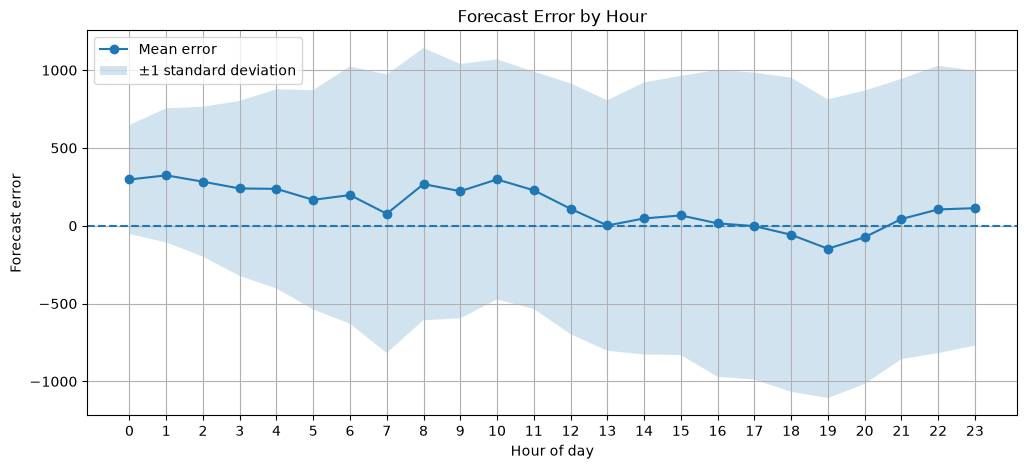

<Figure size 640x480 with 0 Axes>

In [56]:
import matplotlib.pyplot as plt

x = hourly_error["forecast_hour"]
mean = hourly_error["mean_error"]
std = hourly_error["std_error"]

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    mean,
    marker="o",
    label="Mean error"
)

plt.fill_between(
    x,
    mean - std,
    mean + std,
    alpha=0.2,
    label="±1 standard deviation"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Hour of day")
plt.ylabel("Forecast error")
plt.title("Forecast Error by Hour")
plt.xticks(range(24))
plt.legend()
plt.grid(True)

plt.show()
plt.savefig(f"{SAVE_DIR}/forecast_error_by_hour_Mean_std.png", dpi=300)

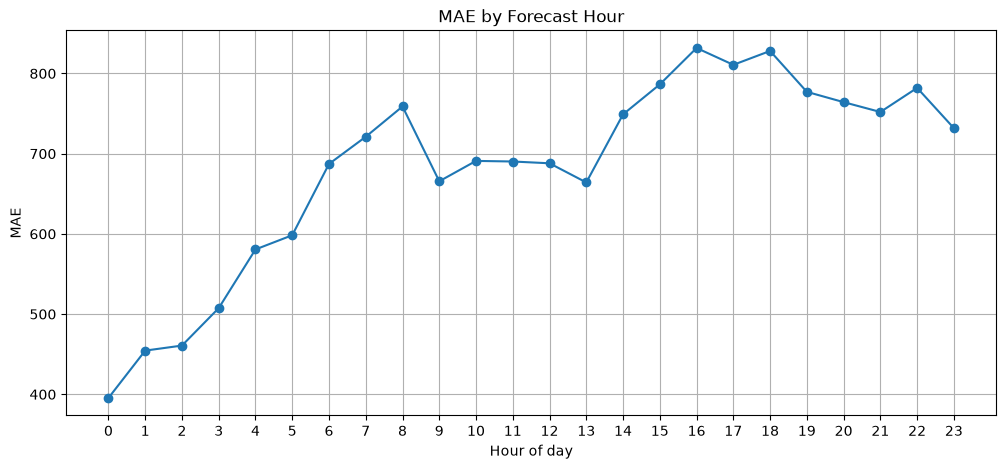

<Figure size 640x480 with 0 Axes>

In [57]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_error["forecast_hour"],
    hourly_error["mae"],
    marker="o"
)

plt.xlabel("Hour of day")
plt.ylabel("MAE")
plt.title("MAE by Forecast Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()
plt.savefig(f"{SAVE_DIR}/forecast_error_by_hour_MAE.png", dpi=300)

Pred shape: (1584,)
Act shape: (1584,)


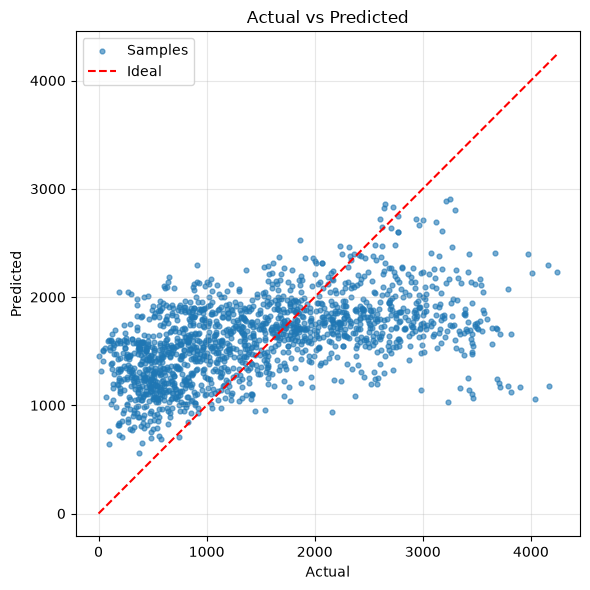

In [58]:
# --- ensure shapes are compatible ---
pred = predictions_original.reshape(-1)
act = actuals_original.reshape(-1)

print("Pred shape:", pred.shape)
print("Act shape:", act.shape)

# --- scatter plot ---
plt.figure(figsize=(6,6))
plt.scatter(act, pred, s=12, alpha=0.6, label="Samples")

# --- 1:1 reference line ---
min_v = min(act.min(), pred.min())
max_v = max(act.max(), pred.max())
plt.plot([min_v, max_v], [min_v, max_v], 'r--', label="Ideal")

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
